In [1]:
import sys
sys.path.append('../../../')
sys.path.append('/home/sheida.rahnamai/GIT/HDN/')
import torch
from sklearn.cluster import HDBSCAN
from tqdm import tqdm
# from lib.dataloader import CustomTestDataset
import tifffile as tiff
import os
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
from math import pi
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from openTSNE import TSNE
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from numba import njit
import numpy as np
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import pickle
from sklearn.manifold import Isomap
from matplotlib.colors import ListedColormap
from glob import glob

In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

dist_metric = ['euclidean']

num_clusters = 4
patch_size = (64,64)
mask_size = 1
label_size = 1
n_channel = 32
hierarchy_level = 3
model_versions = ['']

In [3]:
data_dir = "/group/jug/Sheida/pancreatic beta cells/download/"

One_test_image = ['high_c4']

# Load test image
test_img_path = os.path.join(data_dir, One_test_image[0], f"{One_test_image[0]}_source.tif")
test_images = tiff.imread(test_img_path)

# Print loaded test images paths
print("Test image loaded from path:")
print(test_img_path)

# Load test ground truth images
test_gt_path = os.path.join(data_dir, One_test_image[0], f"{One_test_image[0]}_gt.tif")
test_ground_truth_image = tiff.imread(test_gt_path)

Test image loaded from path:
/group/jug/Sheida/pancreatic beta cells/download/high_c4/high_c4_source.tif


In [4]:
def count_label_pixels(ground_truth):
    # Get unique labels and their counts
    unique_labels, counts = np.unique(ground_truth, return_counts=True)
    
    # Create a dictionary to store label-wise pixel counts
    label_pixel_counts = dict(zip(unique_labels, counts))
    
    return label_pixel_counts

In [5]:
count_label_pixels(test_ground_truth_image)

{-1: 409001638, 0: 107710351, 1: 25910981, 2: 36936035, 3: 23104175}

In [6]:
def select_random_pixels_within_range(ground_truth, labels, pixels_per_class, x_range, y_range, z_range):
    selected_pixels = {}

    for label in labels:
        # Get the coordinates where ground truth equals the label
        coords = np.argwhere(ground_truth == label)
        
        # Filter coordinates based on the specified range
        x_in_range = (coords[:, 2] >= x_range[0]) & (coords[:, 2] <= x_range[1])
        y_in_range = (coords[:, 1] >= y_range[0]) & (coords[:, 1] <= y_range[1])
        z_in_range = (coords[:, 0] >= z_range[0]) & (coords[:, 0] <= z_range[1])
        
        # Keep only the coordinates that satisfy all range conditions
        filtered_coords = coords[z_in_range & y_in_range & x_in_range]
        
        # Check if there are enough pixels for the current label after filtering
        if len(filtered_coords) < pixels_per_class:
            raise ValueError(f"Not enough pixels for label {label} within the specified range. Found {len(filtered_coords)}, required {pixels_per_class}")
        
        # Randomly select pixels_per_class coordinates from filtered_coords
        chosen_indices = np.random.choice(len(filtered_coords), pixels_per_class, replace=False)
        chosen_coords = filtered_coords[chosen_indices]
        
        # Store selected coordinates for the label
        selected_pixels[label] = chosen_coords

    return selected_pixels


In [7]:
labels_of_interest = [0, 1, 2, 3]
z, y, x = test_images.shape
x_range = (32, x - 32)
y_range = (32, y - 32)
z_range = (0, z - 1)

In [8]:
# selected_pixel_coords = select_random_pixels_within_range(test_ground_truth_image, labels_of_interest, pixels_per_class=10240, x_range=x_range, y_range=y_range, z_range=z_range)

In [9]:
def save_as_pickle(selected_pixel_coords, filename):
    with open(filename, 'wb') as f:
        pickle.dump(selected_pixel_coords, f)

def load_pickle(filename):
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    return data
# Usage
# save_as_pickle(selected_pixel_coords, 'selected_pixel_coords.pkl')
selected_pixel_coords = load_pickle('selected_pixel_coords.pkl')

In [10]:
gt = np.zeros((4, 10240), dtype=np.uint8)
# gt = np.zeros((4, 256), dtype=np.uint8)
gt[0] = 0
gt[1] = 1
gt[2] = 2
gt[3] = 3

In [11]:
def extract_patches(image, coords, patch_size=(64,64)):
    half_size_y = patch_size[0] // 2
    half_size_x = patch_size[1] // 2
    patches = []

    # Get the shape of the image
    _, y_max, x_max = image.shape

    for coord in coords:
        z, y, x = coord

        # Calculate the boundaries of the patch
        x_start = max(0, x - half_size_x)
        x_end = min(x_max, x + half_size_x)
        y_start = max(0, y - half_size_y)
        y_end = min(y_max, y + half_size_y)

        
        # Extract the patch from the image
        patch = image[z, y_start:y_end, x_start:x_end]
        
        # Check if the patch is the required size, otherwise pad with zeros
        if patch.shape != patch_size:
            print("something is wrong")

        
        # Store the patch
        patches.append(patch)

    return np.array(patches)

In [12]:
all_patches_tensors = []

for label, coords in selected_pixel_coords.items():
    patches = extract_patches(test_images, coords, patch_size=patch_size)
    patches_tensor = torch.tensor(patches, dtype=torch.float32).unsqueeze(1)
    print(f"Patches for label {label}: {patches_tensor.shape}")  # The shape should be (10240, 64, 64)
    all_patches_tensors.append(patches_tensor)

combined_tensor = torch.stack(all_patches_tensors, dim=0).reshape(320, 128, 1, 64, 64)
# combined_tensor = torch.stack(all_patches_tensors, dim=0).reshape(8, 128, 1, 64, 64)
print(combined_tensor.shape)

Patches for label 0: torch.Size([10240, 1, 64, 64])
Patches for label 1: torch.Size([10240, 1, 64, 64])
Patches for label 2: torch.Size([10240, 1, 64, 64])
Patches for label 3: torch.Size([10240, 1, 64, 64])
torch.Size([320, 128, 1, 64, 64])


In [13]:
def compute_dice_coefficient_v2(ground_truth, predicted):
    """
    Compute Dice coefficient between ground truth and predicted segmentation after resolving label permutations.
    """
    ground_truth = ground_truth.flatten()
    predicted = predicted.flatten()
    
    # Create a confusion matrix
    conf_matrix = confusion_matrix(ground_truth, predicted, labels=[0, 1, 2, 3])
    
    # Initial assignment with Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(-conf_matrix)
    initial_assignment = {gt: pred for gt, pred in zip(row_ind, col_ind)}
    
    # Generate all alternative mappings for ambiguous clusters
    def calculate_dice_for_mapping(mapping):
        remapped_predicted = np.copy(predicted)
        for gt_label, pred_label in mapping.items():
            remapped_predicted[predicted == pred_label] = gt_label
        
        # Compute Dice coefficient for each label
        dice_scores = []
        for label in np.unique(ground_truth):
            gt_binary = (ground_truth == label)
            pred_binary = (remapped_predicted == label)
            intersection = np.sum(gt_binary & pred_binary)
            dice = (2. * intersection) / (np.sum(gt_binary) + np.sum(pred_binary))
            if np.sum(gt_binary) + np.sum(pred_binary) == 0:
                dice = 1.0
            dice_scores.append(dice)
        
        return np.mean(dice_scores), dice_scores
    
    # Evaluate initial mapping
    best_score, best_dice_coefficients = calculate_dice_for_mapping(initial_assignment)
    
    # Check alternative assignments for ambiguous labels
    ambiguous_mappings = [dict(initial_assignment)]
    for gt_label, pred_label in initial_assignment.items():
        # Try switching this cluster to any other GT label
        for alternative_gt in range(conf_matrix.shape[0]):
            if alternative_gt != gt_label and alternative_gt not in initial_assignment:
                alternative_mapping = dict(initial_assignment)
                alternative_mapping[alternative_gt] = pred_label
                ambiguous_mappings.append(alternative_mapping)
    
    # Find the best mapping across all alternatives
    for mapping in ambiguous_mappings:
        score, dice_scores = calculate_dice_for_mapping(mapping)
        if score > best_score:
            best_score = score
            best_dice_coefficients = dice_scores
    
    return best_dice_coefficients


In [14]:
def compute_dice_coefficient(ground_truth, predicted):
    """
    Compute Dice coefficient between ground truth and predicted segmentation after resolving label permutations.
    
    Args:
    - ground_truth (numpy array): Ground truth labels (values from 0 to 3).
    - predicted (numpy array): Predicted labels (after clustering, might be permuted).
    
    Returns:
    - dice_coefficients (list): Dice coefficients for each class (label).
    - remapped_predicted (numpy array): Predicted labels after optimal label assignment.
    """
    # Ensure both arrays are 1D
    ground_truth = ground_truth.flatten()
    predicted = predicted.flatten()
    
    # Create a confusion matrix
    conf_matrix = confusion_matrix(ground_truth, predicted, labels=[0, 1, 2, 3])
    
    # Use the Hungarian algorithm to find the optimal label assignment (best permutation)
    row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # Negative because it's maximization problem
    
    # Re-map predicted labels to match ground truth based on the optimal assignment
    remapped_predicted = np.zeros_like(predicted)
    label_mapping = {}
    
    for gt_label, pred_label in zip(row_ind, col_ind):
        label_mapping[pred_label] = gt_label
        remapped_predicted[predicted == pred_label] = gt_label
    
    # Now check for any unmatched labels
    unique_gt_labels = np.unique(ground_truth)
    unique_pred_labels = np.unique(predicted)
    
    # If any ground truth labels are missing in the prediction, handle them by assigning 0
    for label in unique_gt_labels:
        if label not in label_mapping.values():
            # Assign the next available predicted label to the missing GT class
            missing_pred_label = next(x for x in unique_pred_labels if x not in label_mapping)
            label_mapping[missing_pred_label] = label
            remapped_predicted[predicted == missing_pred_label] = label
    
    # Compute Dice coefficient for each class
    dice_coefficients = []
    for label in unique_gt_labels:
        gt_binary = (ground_truth == label)
        pred_binary = (remapped_predicted == label)
        
        intersection = np.sum(gt_binary & pred_binary)
        dice = (2. * intersection) / (np.sum(gt_binary) + np.sum(pred_binary))
        
        # If both sums are 0, avoid division by zero (assign Dice score of 1 for perfect empty match)
        if np.sum(gt_binary) + np.sum(pred_binary) == 0:
            dice = 1.0
        
        dice_coefficients.append(dice)
    
    return dice_coefficients


In [15]:
@njit
def custom_metric(x, y, alpha=0.9):
    """
    Hybrid distance metric combining Euclidean distance and Cosine similarity.
    
    Parameters:
    x, y: Input vectors.
    alpha: Weighting factor for Euclidean distance (0 <= alpha <= 1).
    
    Returns:
    Hybrid distance as a weighted sum of Euclidean and cosine distances.
    """
    # Euclidean distance
    diff = x - y
    euclidean_distance = np.sqrt(np.sum(diff**2))

    # Cosine similarity
    dot_product = np.dot(x, y)
    norm_x = np.sqrt(np.sum(x**2))
    norm_y = np.sqrt(np.sum(y**2))
    cosine_similarity = dot_product / (norm_x * norm_y + 1e-8)  # Add epsilon to avoid division by zero
    
    # Convert cosine similarity to cosine distance
    cosine_distance = 1 - cosine_similarity

    # Hybrid distance
    hybrid_distance = alpha * euclidean_distance + (1 - alpha) * cosine_distance
    return hybrid_distance



In [16]:
def silhouette_tsne_plot(X, y, cluster_labels, n_clusters=4):

    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Compute the average silhouette score
    silhouette_avg = silhouette_score(X, y)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg}")

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, y)

    # Generate consistent colors for the clusters
    colors = cm.nipy_spectral(np.arange(n_clusters) / n_clusters)

    clusters = ['Unrecognized', 'Nucleus', 'Granules', 'Mitochondria']

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[y == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = colors[i]
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)
        
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i)+':'+clusters[i])
        y_lower = y_upper + 10  # 10 for the blank space between clusters

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xlim([-1, 1])

    # 2nd Plot showing the t-SNE visualization of the clustered data using openTSNE
    # Step 1: Perform t-SNE transformation using openTSNE
    
    # X_cluster_specific = np.zeros((X.shape[0], 2048))

    # for i in range(X.shape[0]):
    #     cluster_label = y[i]
    #     start_idx = cluster_label * 2048
    #     end_idx = start_idx + 2048
    #     # Extract the features corresponding to the cluster
    #     X_cluster_specific[i, :] = X[i, start_idx:end_idx]
    # scaler = StandardScaler()
    # X_cluster_specific = scaler.fit_transform(X_cluster_specific)
    
    # tsne = TSNE(n_components=2, random_state=42, metric="euclidean")
    isomap = Isomap(n_components=2)

    # X_tsne = tsne.fit(X)  # Transform X into 2D space
    X_tsne = isomap.fit_transform(X)

    # Step 2: Plot the t-SNE transformed data in ax2
    tsne_colors = colors[y]  # Use consistent colors for clusters
    ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=tsne_colors, edgecolor="k")

    # Compute visual centers for the clusters in the t-SNE space
    for i in range(n_clusters):
        cluster_points = X_tsne[y == i]
        cluster_center_tsne = np.mean(cluster_points, axis=0)  # Mean of t-SNE points
        ax2.scatter(cluster_center_tsne[0], cluster_center_tsne[1], marker="o", c="white", alpha=1, s=200, edgecolor="k")
        ax2.scatter(cluster_center_tsne[0], cluster_center_tsne[1], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

    ax2.set_title("t-SNE visualization of the clustered data (openTSNE)")
    ax2.set_xlabel("t-SNE component 1")
    ax2.set_ylabel("t-SNE component 2")

    plt.suptitle(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters}",
                fontsize=14, fontweight="bold")

    plt.show()


In [17]:
color_list = [
    '#00CED1',  # Dark Turquoise
    '#3357FF',  # Bright Blue
    '#9400D3',  # Dark Violet
    # '#FF8C00',  # Dark Orange
    '#FF0000',
    '#FF5733',  # Vivid Orange-Red
    '#FF00FF',  # Magenta
]

In [18]:
# Function to create radar charts for multiple experiments
def radar_chart(experiments_data, experiment_labels, title):
    
    classes = ['                 Unrecognized', 'Nucleus', 'Granule       ', 'Mitochondria']
    
    # Number of variables (classes in this case)
    num_vars = len(classes)

    # Compute angle of each axis
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the loop

    # Initialize the radar plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot each experiment's scores
    for i, experiment_scores in enumerate(experiments_data):
        data = experiment_scores + experiment_scores[:1]  # Complete the loop
        ax.plot(angles, data, linewidth=1, linestyle='dashed', color=color_list[i], label=experiment_labels[i])
        ax.fill(angles, data, color=color_list[i], alpha=0.1)

    # Add the class names as labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(classes)


    # Set the range and labels for the radial grid
    ax.set_rlabel_position(45)  # Position the radial labels at 45 degrees
    ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # Define where the radial ticks appear
    ax.set_yticklabels(['', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1.0'], fontsize=10, color='#696969' )  # Define the tick labels
    ax.set_ylim(0, 1)  # Ensure the plot goes from 0 to 1

    # Make the outer circle gray and adjust the gridlines color to gray
    ax.spines['polar'].set_visible(True)  # Make sure the outer spine is visible
    ax.spines['polar'].set_color('gray')  # Set the outer circle (spine) color to gray
    ax.spines['polar'].set_linewidth(1)   # Set the line width of the outer circle

        # First extended data: up to 1.5 radius
    extended_data_1 = [1.0] * num_vars  # Extended boundary at radius 1.5
    extended_data_1 += extended_data_1[:1]  # Complete the loop
    ax.fill(angles, extended_data_1, color='green', alpha=0.04)  # Lighter fill for extension

    # Second extended data: up to 2.0 radius
    extended_data_2 = [0.25] * num_vars  # Extended boundary at radius 2.0
    extended_data_2 += extended_data_2[:1]  # Complete the loop
    ax.fill(angles, extended_data_2, color='red', alpha=0.04)  # Even lighter fill for outer extension
    # Add a floating legend
    plt.legend(loc='upper left', bbox_to_anchor=(-0.3, 1.05))  # Move the legend outside the plot

    # Remove plt.title and use ax.text for full customization
    plt.title(r'Comparison of Cluster-wise $\mathbf{Dice\ Scores}$ for Different Experiments - '+title, 
          size=13, color='black', y=1.1)


    # Show the plot
    plt.show()

In [19]:
model_dir = "/group/jug/Sheida/HVAE/TAC/"
batch_size = 128
def cluster_latent_space(experiment):
    dice_score = []
    for model_v in model_versions:
        model = torch.load(model_dir+experiment+str(model_v)+"/model/EXTAC_best_vae.net")
        data_mean = model.data_mean
        data_std = model.data_std
        model.mode_pred = True
        model.eval()
        device = model.device
        print(f"Processing 1024 pixels with model version {experiment}{model_v}")
        index = 0
        all_mus = np.zeros((40960, 49152), dtype=np.float16)
        # all_mus = np.zeros((1024, 49152), dtype=np.float16)
        with torch.no_grad():
            for batch in combined_tensor:
                batch = batch.to(device)
                batch = (batch - data_mean) / data_std
                output = model(batch)  
                mu_test = torch.cat([output["mu"][i].reshape(batch_size, -1) for i in range(hierarchy_level)], dim=1)
                # mu_test = output["mu"][2].reshape(batch_size, -1)
                mu_test = np.array(mu_test.cpu().numpy())
                all_mus[index:index+batch_size] = mu_test
                index += batch_size

        # Perform K-means clustering
        kmeans = KMeans(n_clusters=4, random_state=42)
        cluster_labels = kmeans.fit_predict(all_mus)
        
        silhouette_tsne_plot(X=all_mus, y=gt.flatten(), cluster_labels=cluster_labels)
        cluster_labels = cluster_labels.reshape(4, 10240)
        # cluster_labels = cluster_labels.reshape(4, 256) #TODO
        # tiff.imwrite(f"{model_dir}{experiment}{model_v}/1000_pixels.tif", cluster_labels)
        tiff.imwrite(f"{model_dir}{experiment}{model_v}/40k_pixels.tif", cluster_labels)
        dice_score.append(compute_dice_coefficient(gt, cluster_labels))
    return dice_score

In [20]:
modes = [
        'supervised_025_percent_hvae_hal',
        'supervised_001_percent_hvae_hal',
        'half_semisupervised_025_percent_hvae_hal',
        'quarter_semisupervised_025_percent_hvae_hal',
        'half_semisupervised_001_percent_hvae_hal',
        'quarter_semisupervised_001_percent_hvae_hal'
        ]

Processing 1024 pixels with model version supervised_025_percent_hvae_hal


/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969118/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv2d(input, weight, bias, self.stride,
/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:91: UserWarning: None of the inputs have requires_grad=True. Gradients 

For n_clusters = 4, the average silhouette_score is: 0.1946474291715859


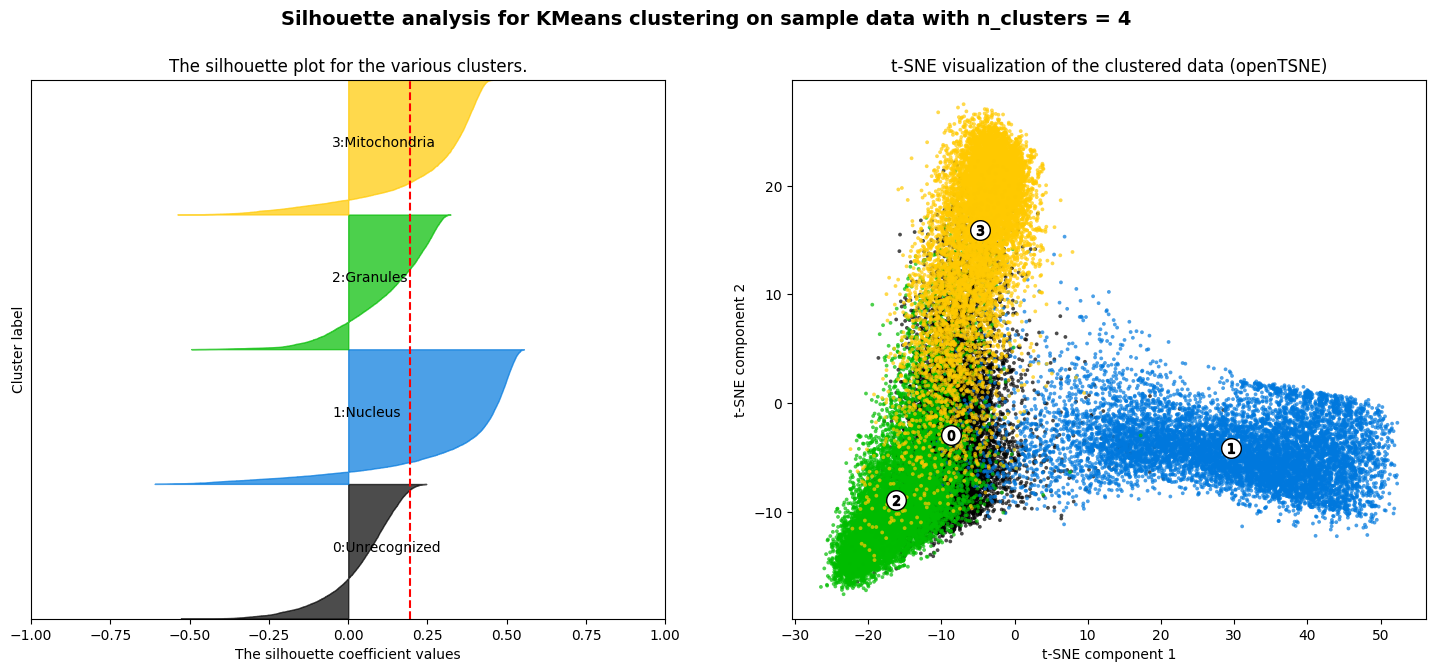

Processing 1024 pixels with model version supervised_001_percent_hvae_hal


/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:91: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


For n_clusters = 4, the average silhouette_score is: 0.17558311870099846


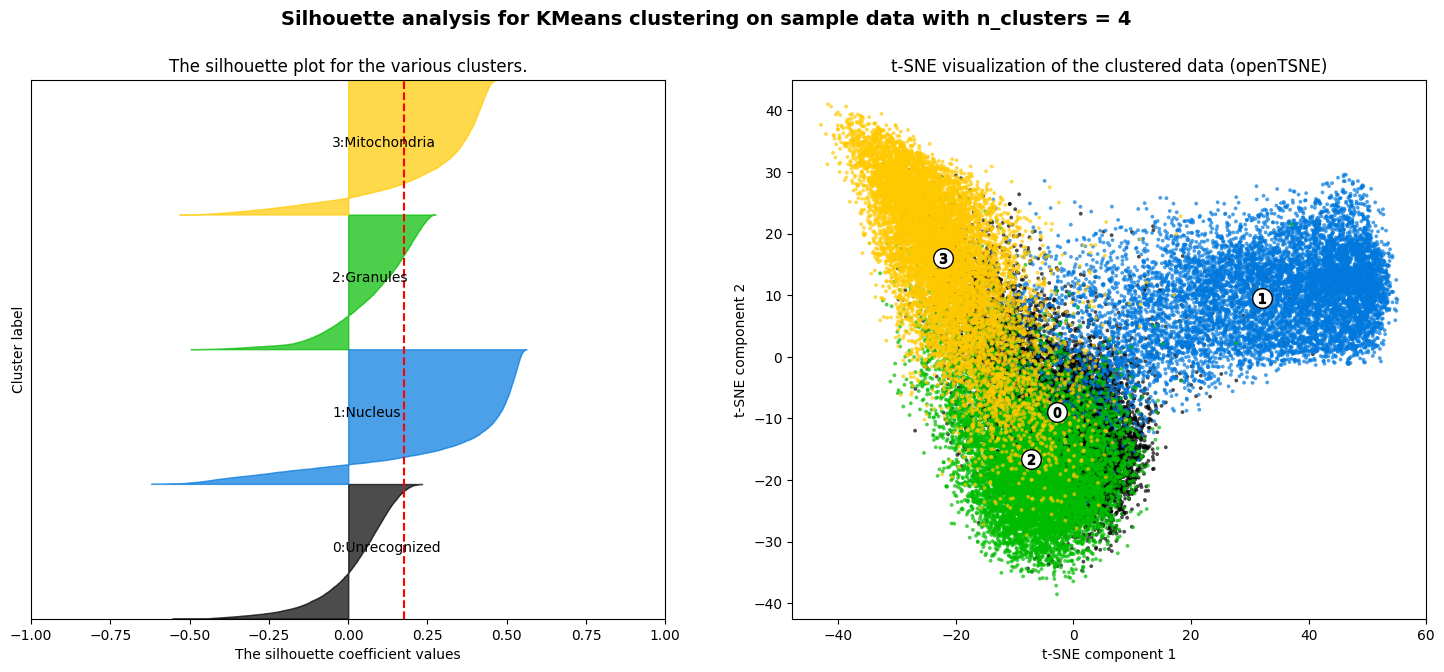

Processing 1024 pixels with model version half_semisupervised_025_percent_hvae_hal


/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:91: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


For n_clusters = 4, the average silhouette_score is: 0.3098788338756989


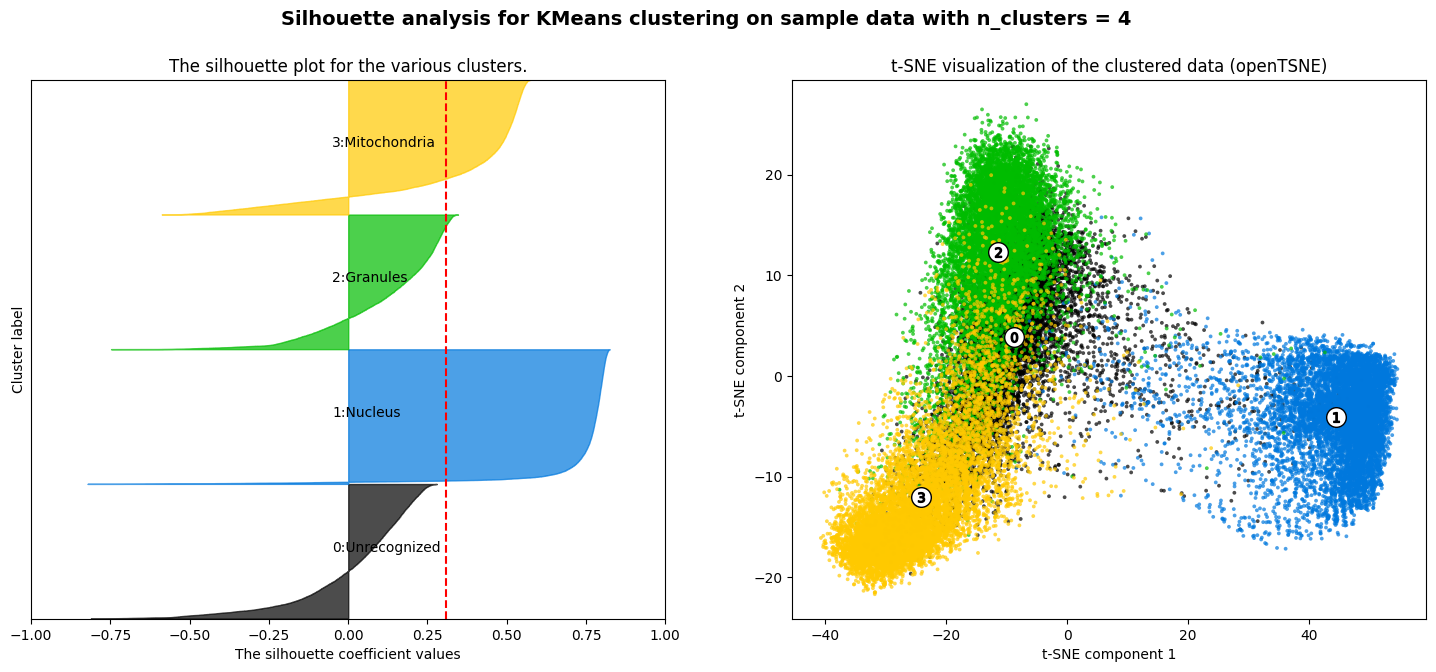

Processing 1024 pixels with model version quarter_semisupervised_001_percent_hvae_hal


/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/sheida.rahnamai/miniconda3/envs/emseg/lib/python3.12/site-packages/torch/utils/checkpoint.py:91: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


For n_clusters = 4, the average silhouette_score is: 0.2567996137207707


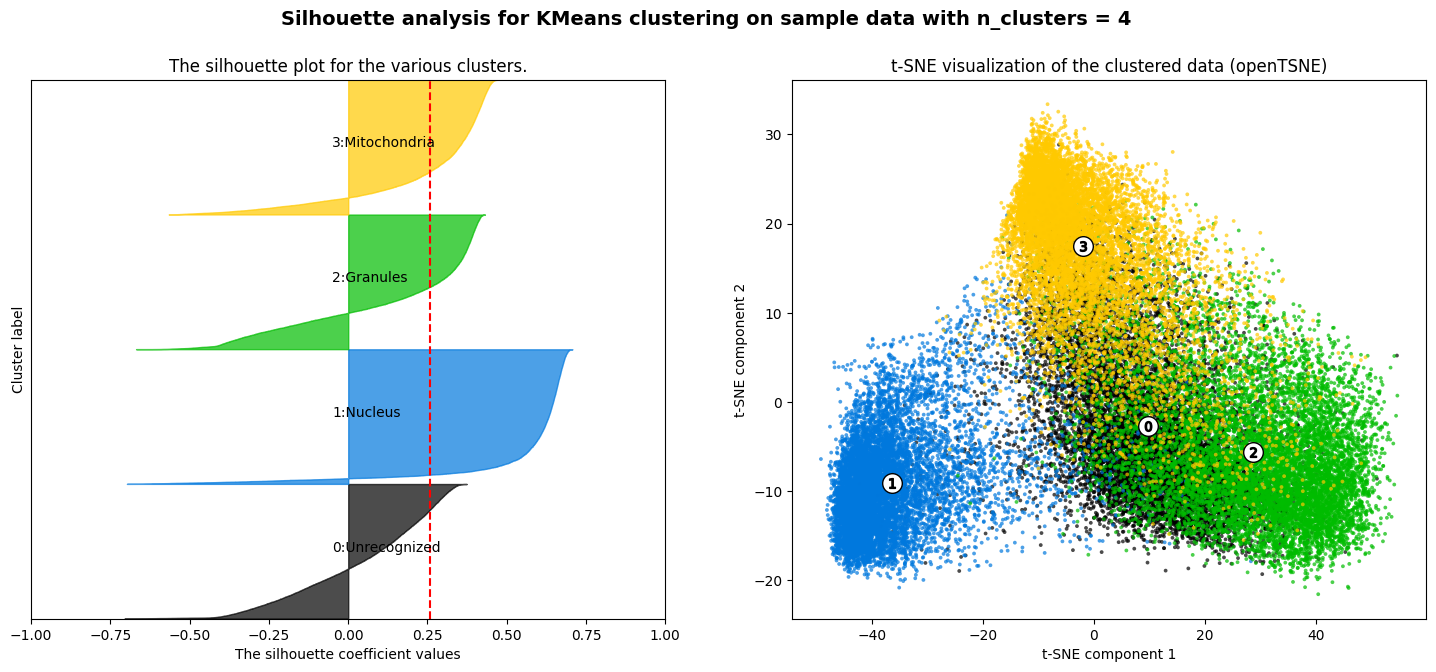

In [21]:
# all_dice_scores = np.zeros((len(modes), len(model_versions)))
for i in range(len(modes)):
    # all_dice_scores[i] = cluster_latent_space(modes[i])
    output = cluster_latent_space(modes[i])

In [22]:
for mode in modes:
    print(mode)
    seg = tiff.imread(f"{model_dir}{mode}/40k_pixels.tif")
    for i in range(4):
        print(count_label_pixels(seg[i]))
    dice_scores = compute_dice_coefficient(gt, seg)
    print(dice_scores)

supervised_025_percent_hvae_hal
{0: 37, 1: 4782, 2: 4109, 3: 1312}
{0: 9347, 1: 226, 2: 440, 3: 227}
{0: 1, 1: 7561, 2: 2425, 3: 253}
{1: 364, 2: 834, 3: 9042}
[0.4553413120567376, 0.9525605095541402, 0.6525698010615802, 0.8581190092056563]
supervised_001_percent_hvae_hal
{0: 22, 1: 8375, 2: 205, 3: 1638}
{0: 6167, 1: 424, 2: 3411, 3: 238}
{0: 1, 1: 9407, 2: 12, 3: 820}
{1: 951, 2: 37, 3: 9252}
[0.029485796476087737, 0.7506999391357273, 0.6399972786338742, 0.8339643050297458]
half_semisupervised_025_percent_hvae_hal
{0: 245, 1: 5382, 2: 584, 3: 4029}
{0: 10098, 1: 60, 2: 1, 3: 81}
{0: 17, 1: 2172, 2: 226, 3: 7825}
{0: 6, 1: 2278, 2: 7794, 3: 162}
[0.5346711702761773, 0.9801028826555372, 0.7006312396472221, 0.8271690103475723]
quarter_semisupervised_025_percent_hvae_hal
{0: 1743, 1: 1697, 2: 3981, 3: 2819}
{0: 6259, 1: 5, 2: 16, 3: 3960}
{0: 181, 1: 5287, 2: 4189, 3: 583}
{0: 4311, 1: 148, 2: 321, 3: 5460}
[0.4247079532725236, 0.5506290138119116, 0.608505495770271, 0.47350620067643745]


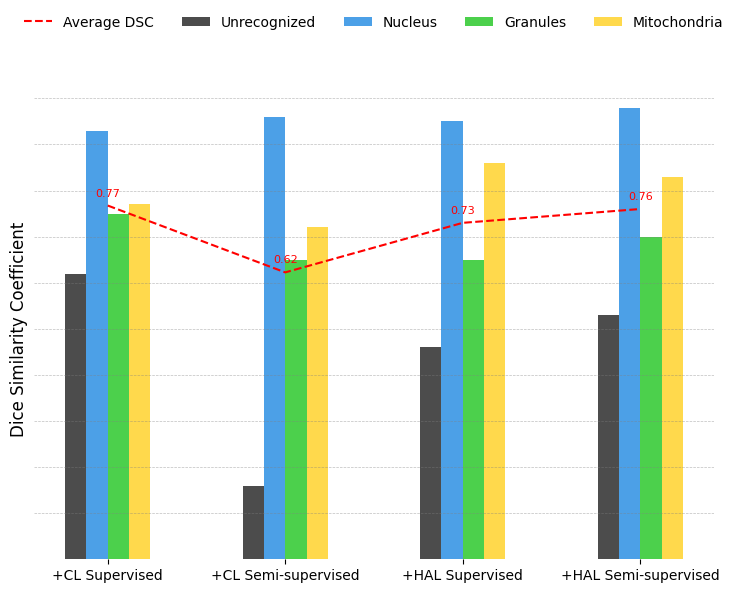

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Data
methods = ["+CL Supervised", "+CL Semi-supervised", "+HAL Supervised", "+HAL Semi-supervised"]
# supervised_025_percent_hvae_cl
# [0.6200652528548124, 0.9328548395485515, 0.7515702000193255, 0.7717310443490701]
# semisupervised_025_percent_hvae_cl
# [0.15710480150737444, 0.964247894710302, 0.6492311736101984, 0.7202066166523183]

# supervised_025_percent_hvae_hal
# [0.4553413120567376, 0.9525605095541402, 0.6525698010615802, 0.8581190092056563]
# semisupervised_025_percent_hvae_hal
# [0.5346711702761773, 0.9801028826555372, 0.7006312396472221, 0.8271690103475723]


class_scores = {
    "Unrecognized": [0.62, 0.16, 0.46, 0.53],
    "Nucleus": [0.93, 0.96, 0.95, 0.98],
    "Granules": [0.75, 0.65, 0.65, 0.70],
    "Mitochondria": [0.77, 0.72, 0.86, 0.83],
}

# Calculate average scores
n_classes = len(class_scores)
average_scores = [np.mean([scores[i] for scores in class_scores.values()]) for i in range(len(methods))]

# Colors from colormap
colors = cm.nipy_spectral(np.arange(n_classes) / n_classes)
clusters = list(class_scores.keys())

# Bar positions
x = np.arange(len(methods))  # positions for the methods
bar_width = 0.12  # Thinner bars

# Plotting
plt.figure(figsize=(8, 6))

# Add gray horizontal lines for scale
for y in np.arange(0, 1.1, 0.1):  # Scale from 0 to 1 with a step of 0.1
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Bars for each cluster
for i, cluster in enumerate(clusters):
    offset = (i - (n_classes - 1) / 2) * bar_width
    plt.bar(
        x + offset,
        class_scores[cluster],
        width=bar_width,
        color=colors[i],
        alpha=0.7,
        label=cluster,  # No edgecolor specified, removes border
    )

# Plot average line
plt.plot(x, average_scores, linestyle="--", color="red", linewidth=1.5, label="Average DSC")

# Customization for minimalism with scale
plt.xticks(x, methods, fontsize=10, color='black')  # Show method names only
plt.yticks([])  # Remove y-axis numbers
plt.gca().spines['top'].set_visible(False)  # Hide top border
plt.gca().spines['right'].set_visible(False)  # Hide right border
plt.gca().spines['left'].set_visible(False)  # Hide left border
plt.gca().spines['bottom'].set_visible(False)  # Hide bottom border

# Add "DSC" label on the y-axis
plt.text(-0.5, 0.5, "Dice Similarity Coefficient", fontsize=12, color="black", ha="center", va="center", rotation="vertical")

# Move legend above the plot
plt.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=5, frameon=False)

# Annotate the average values
for i, avg in enumerate(average_scores):
    plt.text(x[i], avg + 0.02, f"{avg:.2f}", ha="center", fontsize=8, color="red")

# Show the Plot
plt.tight_layout()
plt.show()


In [ ]:
for mode in modes:
    print(mode)
    seg = tiff.imread(f"{model_dir}{mode}/1000pixels.tif")
    for i in range(4):
        print(count_label_pixels(seg[i]))
    dice_scores = compute_dice_coefficient(gt, seg)
    print(dice_scores)

In [ ]:
lbls = ['5 - 5', '5 - 3', '5 - 1', '3 - 3', '3 - 1', '1 - 1']
experiments_data = [
[0.6992753623188406, 0.9783889980353635, 0.7308533916849015, 0.8603773584905661],
[0.3230088495575221, 0.8983050847457628, 0.7302752293577982, 0.6666666666666666],
[0.336, 0.6025236593059937, 0.5359477124183006, 0.2945054945054945],
[0.6555555555555556, 0.9488752556237219, 0.7222222222222222, 0.8211243611584327],
[0.4716312056737589, 0.9516129032258065, 0.7577639751552795, 0.5108910891089109],
[0.7374301675977654, 0.9782178217821782, 0.788546255506608, 0.8659420289855072],
]
# Create the radar chart
radar_chart(experiments_data, lbls, '')

In [ ]:
import numpy as np
import torch

def generate_high_dim_simplex(num_dims=2048, desired_distance=1.0):
    # Starting points for a regular simplex (tetrahedron) in 3D
    base_points = np.array([
        [1, 1, 1],
        [1, -1, -1],
        [-1, 1, -1],
        [-1, -1, 1]
    ]) * (desired_distance / np.sqrt(2))  # Scale to achieve desired pairwise distance

    # Embed these 3D points into the high-dimensional space
    high_dim_points = np.zeros((4, num_dims))
    high_dim_points[:, :3] = base_points  # Place the 3D simplex points in the first 3 dimensions
    for x in high_dim_points[0]:
        if x != 0:
            print(x)

    return high_dim_points

# Example usage
num_dims = 32 * 8 * 8  # Flattened size
desired_distance = 8.0  # Set the desired pairwise distance
points = generate_high_dim_simplex(num_dims=num_dims, desired_distance=desired_distance)

# Convert to torch tensor
points_torch = torch.tensor(points, dtype=torch.float32)

# Compute pairwise distances using torch.cdist
pairwise_distances_torch = torch.cdist(points_torch, points_torch, p=2)
print("Pairwise distances (Torch):\n", pairwise_distances_torch)


In [ ]:
import numpy as np
import torch
scale = 8 / np.sqrt(2)
base_points = np.array([
        [1, 1, 1],
        [1, -1, -1],
        [-1, 1, -1],
        [-1, -1, 1]
    ]) * scale
chunk_values = np.concatenate([
                np.zeros((4, 32, 8, 8)),   
            ], axis=0)  # Concatenate along the channel dimension
chunk_values[0, :3, 3, 3] = torch.tensor(base_points[0])
chunk_values[1, :3, 3, 3] = torch.tensor(base_points[1])
chunk_values[2, :3, 3, 3] = torch.tensor(base_points[2])
chunk_values[3, :3, 3, 3] = torch.tensor(base_points[3])

In [ ]:
# Verify by computing pairwise distances between groups
def pairwise_group_distances(tensor):
    groups = [tensor[i].flatten() for i in range(4)]
    distances = torch.cdist(torch.stack(groups), torch.stack(groups), p=2)
    return distances

In [ ]:
pairwise_group_distances(torch.tensor(chunk_values).float())

In [ ]:
# conditional_sampling
# For n_clusters = 4, the average silhouette_score is: -0.004533758884071582
seg = tiff.imread(f"{model_dir}conditional_sampling/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
# GMM_crossentropy
# For n_clusters = 4, the average silhouette_score is: -0.02669500853725512
seg = tiff.imread(f"{model_dir}GMM_crossentropy/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
# GMM_with_CL
# For n_clusters = 4, the average silhouette_score is: -0.03477334309883852
seg = tiff.imread(f"{model_dir}GMM_with_CL/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
# GMM_with_CE
# For n_clusters = 4, the average silhouette_score is: -0.17922090417078865
seg = tiff.imread(f"{model_dir}GMM_with_CE/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
# GMM_without_CL
# For n_clusters = 4, the average silhouette_score is: -0.13549815717197797
seg = tiff.imread(f"{model_dir}GMM_without_CL/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
# NG_with_CL
# For n_clusters = 4, the average silhouette_score is: 0.35026349504854704
seg = tiff.imread(f"{model_dir}NG_with_CL/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
# NG_without_CL
# For n_clusters = 4, the average silhouette_score is: -0.004122317354126628
seg = tiff.imread(f"{model_dir}NG_without_CL/1000pixels.tif")
for i in range(4):
    print(count_label_pixels(seg[i]))
dice_scores = compute_dice_coefficient(gt, seg)
print(dice_scores)

In [ ]:
experiments_data = [
[0.6594885598923284, 0.9718875502008032, 0.7610208816705336, 0.6276595744680851],
[0.7189349112426036, 0.9821782178217822, 0.8583509513742071, 0.6802030456852792],
[0.691437802907916, 0.98635477582846, 0.8365180467091295, 0.7415730337078652],
[0.7034277198211625, 0.9678714859437751, 0.8418803418803419, 0.7104622871046229],
[0.6715542521994134, 0.9739478957915831, 0.8577319587628865, 0.5968586387434555],
[0.7475728155339806, 0.9724409448818898, 0.8469601677148847, 0.7910112359550562],
]
experiment_labels = ['5x5 - 5x5', '5x5 - 3x3', '5x5 - 1x1', '3x3 - 3x3', '3x3 - 1x1', '1x1 - 1x1']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'supervised')


In [ ]:
experiments_data = [
[0.49950641658440276, 0.9421487603305785, 0.08921933085501858, 0.15602836879432624],
[0.5808823529411765, 0.9510204081632653, 0.6764705882352942, 0.4311377245508982],
[0.6572237960339944, 0.9763779527559056, 0.7392290249433107, 0.6717557251908397],
[0.6210392902408112, 0.8989247311827957, 0.6516290726817042, 0.6683544303797468],
[0.6321525885558583, 0.9614604462474645, 0.7139479905437353, 0.6180904522613065],
[0.7281553398058253, 0.96579476861167, 0.7651006711409396, 0.8477366255144033],

]
experiment_labels = ['5x5 - 5x5', '5x5 - 3x3', '5x5 - 1x1', '3x3 - 3x3', '3x3 - 1x1', '1x1 - 1x1']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'Semi-supervised using 10% GT')


In [ ]:
experiments_data = [
[0.484251968503937, 0.8108108108108109, 0.07434944237918216, 0.11285266457680251],
[0.4969574036511156, 0.8148148148148148, 0.0, 0.175],
[0.46296296296296297, 0.8796498905908097, 0.18285714285714286, 0.21220159151193635],
[0.5242937853107345, 0.968503937007874, 0.2848297213622291, 0.3855421686746988],
[0.4681372549019608, 0.8175519630484989, 0.3865168539325843, 0.192090395480226],
[0.5261744966442953, 0.9040511727078892, 0.41995841995842, 0.48158640226628896],
]
experiment_labels = ['5x5 - 5x5', '5x5 - 3x3', '5x5 - 1x1', '3x3 - 3x3', '3x3 - 1x1', '1x1 - 1x1']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'Semi-supervised using 1% GT')


In [ ]:
experiments_data = [
[0.6594885598923284, 0.9718875502008032, 0.7610208816705336, 0.6276595744680851],
[0.49950641658440276, 0.9421487603305785, 0.08921933085501858, 0.15602836879432624],
[0.484251968503937, 0.8108108108108109, 0.07434944237918216, 0.11285266457680251],
]
experiment_labels = ['suprvised', 'semi-supervised using 10% GT', 'semi-supervised using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 5x5 - label size 5x5')


In [ ]:
experiments_data = [
[0.7189349112426036, 0.9821782178217822, 0.8583509513742071, 0.6802030456852792],
[0.5808823529411765, 0.9510204081632653, 0.6764705882352942, 0.4311377245508982],
[0.4969574036511156, 0.8148148148148148, 0.0, 0.175],
]
experiment_labels = ['suprvised', 'semi-supervised using 10% GT', 'semi-supervised using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 5x5 - label size 3x3')


In [ ]:
experiments_data = [
[0.691437802907916, 0.98635477582846, 0.8365180467091295, 0.7415730337078652],
[0.6572237960339944, 0.9763779527559056, 0.7392290249433107, 0.6717557251908397],
[0.46296296296296297, 0.8796498905908097, 0.18285714285714286, 0.21220159151193635],
]
experiment_labels = ['suprvised', 'semi-supervised using 10% GT', 'semi-supervised using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 5x5 - label size 1x1')


In [ ]:
experiments_data = [
[0.7034277198211625, 0.9678714859437751, 0.8418803418803419, 0.7104622871046229],
[0.6210392902408112, 0.8989247311827957, 0.6516290726817042, 0.6683544303797468],
[0.5242937853107345, 0.968503937007874, 0.2848297213622291, 0.3855421686746988],
]
experiment_labels = ['suprvised', 'semi-supervised using 10% GT', 'semi-supervised using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 3x3 - label size 3x3')


In [ ]:
experiments_data = [
[0.6715542521994134, 0.9739478957915831, 0.8577319587628865, 0.5968586387434555],
[0.6321525885558583, 0.9614604462474645, 0.7139479905437353, 0.6180904522613065],
[0.4681372549019608, 0.8175519630484989, 0.3865168539325843, 0.192090395480226],
]
experiment_labels = ['suprvised', 'semi-supervised using 10% GT', 'semi-supervised using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 3x3 - label size 1x1')


In [ ]:
experiments_data = [
[0.7475728155339806, 0.9724409448818898, 0.8469601677148847, 0.7910112359550562],
[0.7281553398058253, 0.96579476861167, 0.7651006711409396, 0.8477366255144033],
[0.5261744966442953, 0.9040511727078892, 0.41995841995842, 0.48158640226628896],
]
experiment_labels = ['suprvised', f'semi-supervised using 10% GT', f'semi-supervised using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 1x1 - label size 1x1')


In [ ]:
model_dir = "/group/jug/Sheida/HVAE/2D/"
model_versions = ['KL for CL']
batch_size = 128
for model_v in model_versions:
    model = torch.load(model_dir+"test/model/2D_HVAE_best_vae.net")
    data_mean = model.data_mean
    data_std = model.data_std
    model.mode_pred = True
    model.eval()
    device = model.device
    print(f"Processing 1024 pixels with model version supervised {model_v}")
    index = 0 
    all_mus = np.zeros((1024, 43008), dtype=np.float16)
    with torch.no_grad():
        for batch in tqdm(combined_tensor):
            batch = batch.to(device)
            batch = (batch - data_mean) / data_std
            output = model(batch)
            mu_test = torch.cat([output["mu"][i].reshape(batch_size, -1) for i in range(hierarchy_level)], dim=1)
            mu_test = np.array(mu_test.cpu().numpy())
            all_mus[index:index+batch_size] = mu_test
            index += batch_size

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(all_mus)
    cluster_labels = cluster_labels.reshape(4, 256)
    tiff.imwrite(f"{model_dir}test/1000pixels.tif", cluster_labels)

In [ ]:
seg_test = []
for i in range(len(model_versions)):
    seg_test.append(tiff.imread(f"{model_dir}test/1000pixels.tif"))
    for j in range(4):
        print(count_label_pixels(seg_test[i][j]))

In [ ]:
for i in range(len(seg_test)):
    dice_scores, remapped = compute_dice_coefficient(gt, seg_test[i])
    print(f"Model version supervised {model_versions[i]}:")
    print(dice_scores)
    print(silhouette_score(all_mus, remapped, metric='cosine'))

In [ ]:
experiments_data = [
[0.7475728155339806, 0.9724409448818898, 0.8469601677148847, 0.7910112359550562],
[0.7281553398058253, 0.96579476861167, 0.7651006711409396, 0.8477366255144033],
[0.5261744966442953, 0.9040511727078892, 0.41995841995842, 0.48158640226628896],
[0.7953410981697171, 0.974155069582505, 0.8631578947368421, 0.8827292110874201],
[0.7430340557275542, 0.9614604462474645, 0.789587852494577, 0.8348214285714286],
[0.24074074074074073, 0.9380863039399625, 0.4494949494949495, 0.6188679245283019]
]
experiment_labels = ['suprvised', 'semi-supervised using 10% GT', 'semi-supervised using 1% GT', 'KL for CL', 'KL for CL using 10% GT', 'KL for CL using 1% GT']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'mask size 1x1 - label size 1x1')

In [ ]:
model_dir = "/group/jug/Sheida/HVAE/2D/"
model_versions = ['supervised_1x1_with_5x5_data']
batch_size = 128
for model_v in model_versions:
    model = torch.load(model_dir+model_v+"/model/2D_HVAE_best_vae.net")
    data_mean = model.data_mean
    data_std = model.data_std
    model.mode_pred = True
    model.eval()
    device = model.device
    print(f"Processing 1024 pixels with model version {model_v}")
    index = 0 
    all_mus = np.zeros((1024, 43008), dtype=np.float16)
    with torch.no_grad():
        for batch in tqdm(combined_tensor):
            batch = batch.to(device)
            batch = (batch - data_mean) / data_std
            output = model(batch)
            mu_test = torch.cat([output["mu"][i].reshape(batch_size, -1) for i in range(hierarchy_level)], dim=1)
            mu_test = np.array(mu_test.cpu().numpy())
            all_mus[index:index+batch_size] = mu_test
            index += batch_size

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(all_mus)
    cluster_labels = cluster_labels.reshape(4, 256)
    tiff.imwrite(f"{model_dir}{model_v}/1000pixels.tif", cluster_labels)

In [ ]:
seg_less_data = []
for i in range(len(model_versions)):
    seg_less_data.append(tiff.imread(f"{model_dir}{model_versions[i]}/1000pixels.tif"))
    for j in range(4):
        print(count_label_pixels(seg_less_data[i][j]))

In [ ]:
for i in range(len(seg_less_data)):
    dice_scores = compute_dice_coefficient(gt, seg_less_data[i])
    print(f"Model version supervised {model_versions[i]}:")
    print(dice_scores)

In [ ]:
experiments_data = [
[0.6586021505376344, 0.9698189134808853, 0.7563805104408353, 0.6223404255319149],
[0.6904376012965965, 0.984375, 0.8432203389830508, 0.738255033557047],
[0.7487844408427877, 0.9743589743589743, 0.8469601677148847, 0.7919463087248322],
[0.7336377473363774, 0.976, 0.7982261640798226, 0.8]
]
experiment_labels = ['5x5 - 5x5', '5x5 - 1x1', '1x1 - 1x1', '1x1 - 5x5']

# Create the radar chart
radar_chart(experiments_data, experiment_labels, 'supervised')

